In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("/content/sample_data/kmeans.csv", header=None)
df.columns = ['Feature 1', 'Feature 2']
X = df.values


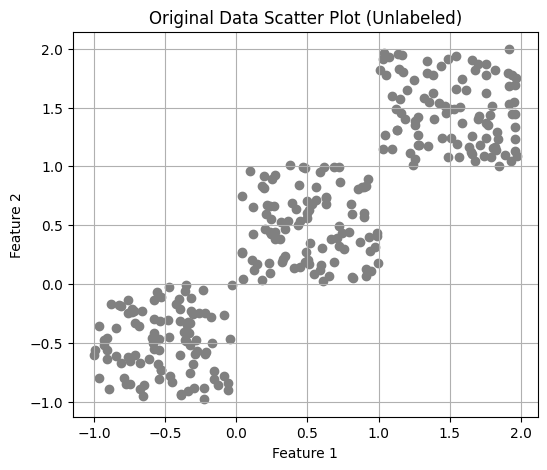

In [2]:

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c='gray')
plt.title("Original Data Scatter Plot (Unlabeled)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


In [3]:

def euclidean_distance(a, b):
    return np.linalg.norm(a - b, axis=1)

def custom_kmeans(X, k, max_iters=10):
    np.random.seed(42)
    centroids = X[np.random.choice(range(len(X)), k, replace=False)]
    all_centroids = [centroids.copy()]
    for _ in range(max_iters):
        distances = np.array([euclidean_distance(X, centroid) for centroid in centroids])
        labels = np.argmin(distances, axis=0)
        new_centroids = np.array([
            X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else centroids[i]
            for i in range(k)
        ])
        all_centroids.append(new_centroids.copy())
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids, all_centroids

# Run for K=3
k = 3
labels, final_centroids, centroids_per_iter = custom_kmeans(X, k)


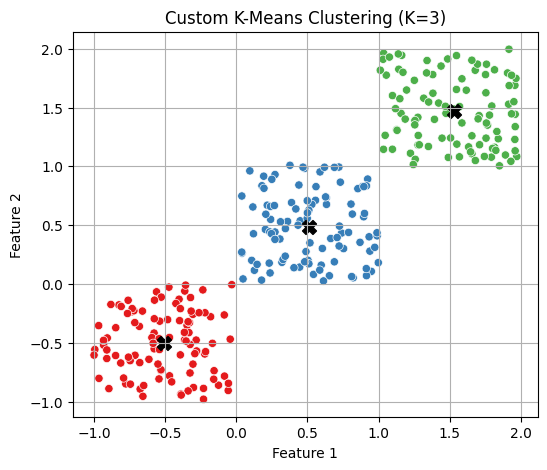

In [4]:

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette='Set1', legend=False)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='black', marker='X', s=100)
plt.title(f"Custom K-Means Clustering (K={k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


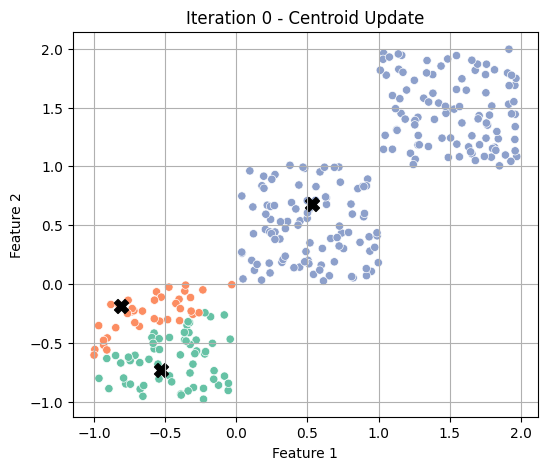

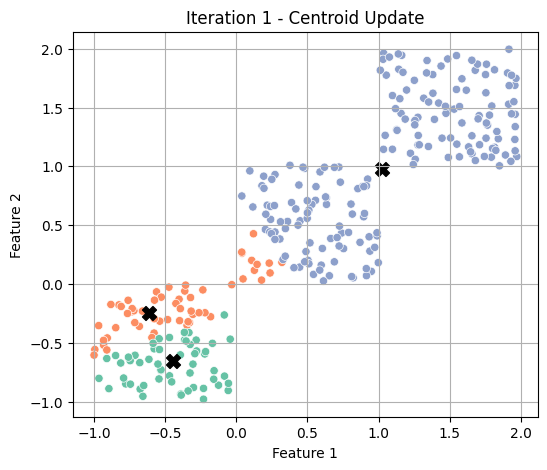

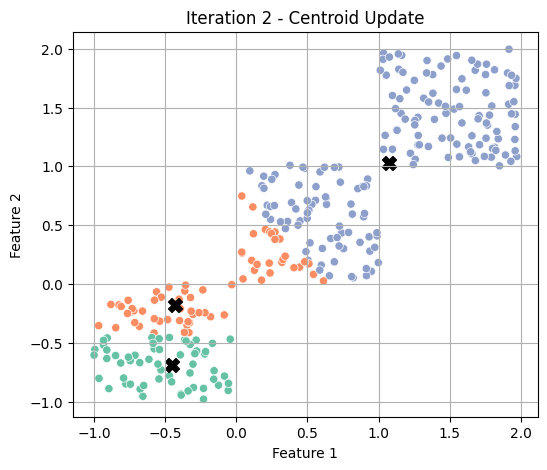

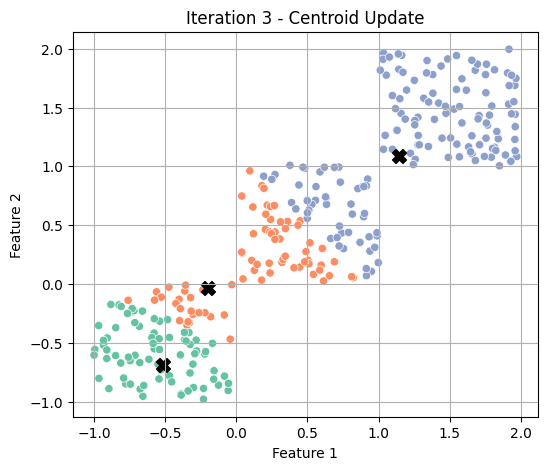

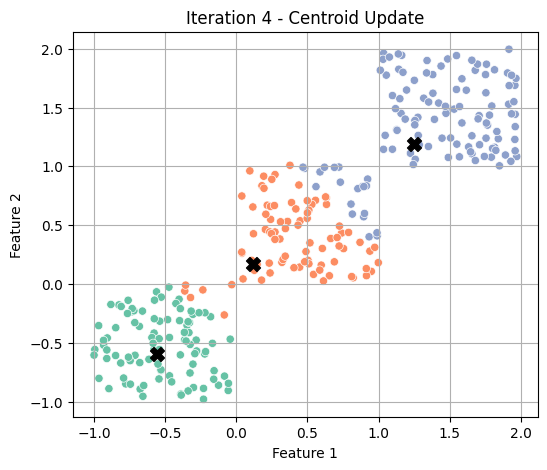

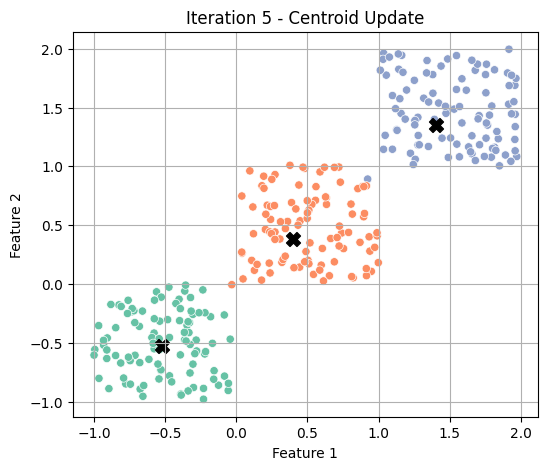

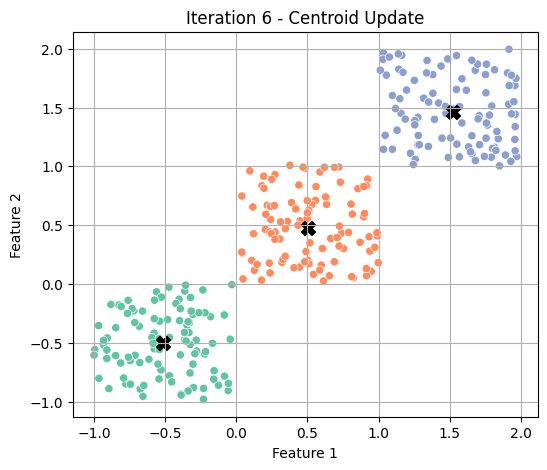

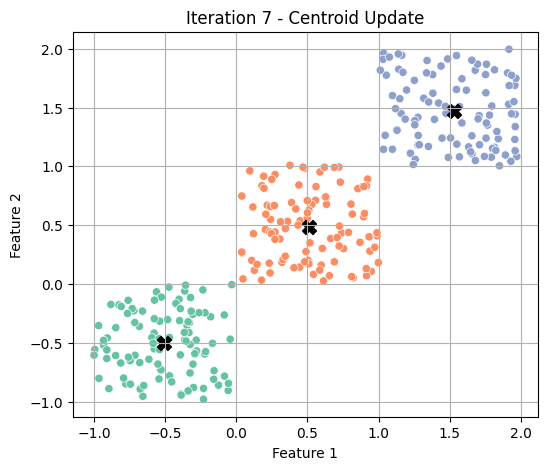

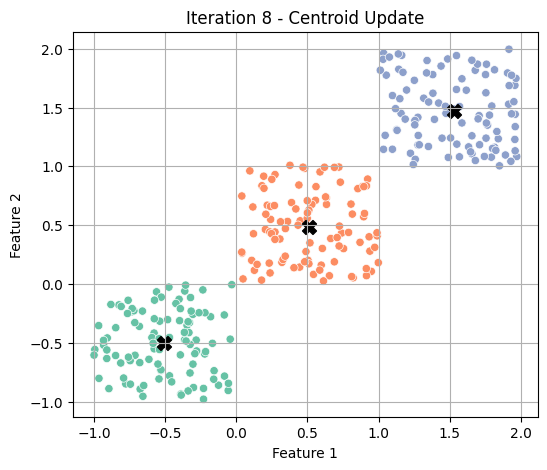

In [5]:

for i, centroids in enumerate(centroids_per_iter):
    plt.figure(figsize=(6, 5))
    distances = np.array([euclidean_distance(X, centroid) for centroid in centroids])
    step_labels = np.argmin(distances, axis=0)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=step_labels, palette='Set2', legend=False)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=100)
    plt.title(f"Iteration {i} - Centroid Update")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()


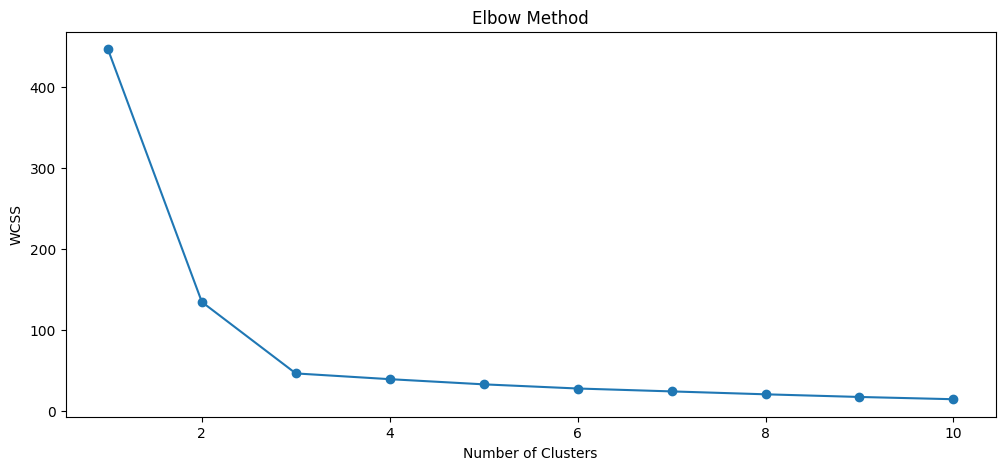

In [13]:

wcss = []
sil_scores = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    wcss.append(model.inertia_)


plt.figure(figsize=(12, 5))
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()
